In [17]:
import pandas as pd
import numpy as np
import os
import pyBigWig

# ==============================================================================
# 1. 参数配置
# ==============================================================================
input_file = '675723-0427605772.targeted.GRCh38Decoy.markdup.CG.num_modc_cxreport.txt'
chrom_sizes_file = 'hg38.chrom.sizes'
output_bw = 'gScr_dCas9_5modc.bw'

temp_unsorted = 'temp_unsorted_raw.bg'
temp_sorted = 'temp_sorted_raw.bg'

# ==============================================================================
# 2. 步骤 1/3: 严格保留原始绝对坐标，原地合并正负链计数
# ==============================================================================
print("步骤 1/3: 正在分块读取并原地归并同坐标的正负链计数...")

chunks = pd.read_csv(input_file, sep='\t', header=None, chunksize=1000000)
first_chunk = True

for chunk in chunks:
    df = pd.DataFrame()
    df['chrom'] = chunk[0].astype(str)  # 强制转换为字符串，防止 X/Y 染色体类型混乱
    df['pos'] = chunk[1]
    df['mod'] = chunk[3]
    df['unmod'] = chunk[4]
    
    chunk_collapsed = df.groupby(['chrom', 'pos']).agg({
        'mod': 'sum',
        'unmod': 'sum'
    }).reset_index()
    
    mode = 'w' if first_chunk else 'a'
    chunk_collapsed.to_csv(temp_unsorted, sep='\t', index=False, header=False, mode=mode)
    first_chunk = False

# ==============================================================================
# 3. 步骤 2/3: 利用 Linux sort 进行全局基因组排序
# ==============================================================================
print("步骤 2/3: 正在进行全基因组坐标排序...")
os.system(f"sort -k1,1 -k2,2n {temp_unsorted} > {temp_sorted}")

if os.path.exists(temp_unsorted):
    os.remove(temp_unsorted)

# ==============================================================================
# 4. 步骤 3/3: 逐条染色体完整加载，精准写入 BigWig（彻底杜绝 X 染色体丢失）
# ==============================================================================
print("步骤 3/3: 正在加载染色体大小并构建 BigWig 文件...")

chrom_order = []
chrom_sizes_dict = {}
with open(chrom_sizes_file, 'r') as f:
    for line in f:
        if line.strip():
            parts = line.split()
            chrom_order.append(parts[0]) 
            chrom_sizes_dict[parts[0]] = int(parts[1])

bw = pyBigWig.open(output_bw, "w")
bw.addHeader([(chrom, chrom_sizes_dict[chrom]) for chrom in chrom_order])

print("正在全量读取排序后的文件...")
# 一次性读入已排序且合并过的中间文件（此时文件由于经过聚合，行数已大幅压减，可安全读入内存）
all_data = pd.read_csv(temp_sorted, sep='\t', header=None, names=['chrom', 'pos', 'mod', 'unmod'])
all_data['chrom'] = all_data['chrom'].astype(str)

print(f"正在逐条染色体计算并安全写入 {output_bw} ...")

for chrom in chrom_order:
    # 自动兼容 chrX 还是 X 的命名问题
    # 如果标头文件带 chr 但数据不带，或者反过来，进行容错转换
    alt_chrom = chrom.replace('chr', '') if 'chr' in chrom else f"chr{chrom}"
    
    chrom_sub = all_data[(all_data['chrom'] == chrom) | (all_data['chrom'] == alt_chrom)].copy()
    
    if chrom_sub.empty:
        print(f"  ⚠️ 警告: 未在数据中发现染色体 {chrom} 的信号，跳过。")
        continue
        
    # 按当前染色体合并可能由于边界产生的极少数同坐标行
    chrom_grouped = chrom_sub.groupby('pos').sum().reset_index()
    
    # 计算总 Coverage
    chrom_grouped['coverage'] = chrom_grouped['mod'] + chrom_grouped['unmod']
    
    # ⭐ 设定最小门槛为 1，确保防除零保护
    chrom_grouped = chrom_grouped[chrom_grouped['coverage'] >= 1].copy()
    
    if chrom_grouped.empty:
        continue
        
    # 计算实际单碱基修饰概率
    chrom_grouped['rate'] = chrom_grouped['mod'] / chrom_grouped['coverage']
    
    # 严格升序排序
    chrom_grouped = chrom_grouped.sort_values('pos')
    
    # 转换写入格式
    chroms_list = [chrom] * len(chrom_grouped)
    starts = chrom_grouped['pos'].astype(int).tolist()
    ends = (chrom_grouped['pos'] + 1).astype(int).tolist()
    values = chrom_grouped['rate'].astype(float).tolist()
    
    print(f"  正在写入染色体 {chrom} ，共 {len(starts)} 个单碱基位点...")
    bw.addEntries(chroms_list, starts, ends=ends, values=values)

bw.close()

if os.path.exists(temp_sorted):
    os.remove(temp_sorted)

print(f"\n🎉 完美修复成功！X染色体及全基因组数据已无损、完整写入：{output_bw}")

步骤 1/3: 正在分块读取并原地归并同坐标的正负链计数...
步骤 2/3: 正在进行全基因组坐标排序...
步骤 3/3: 正在加载染色体大小并构建 BigWig 文件...
正在全量读取排序后的文件...
正在逐条染色体计算并安全写入 gScr_dCas9_5modc.bw ...
  正在写入染色体 chr1 ，共 990196 个单碱基位点...
  正在写入染色体 chr2 ，共 780007 个单碱基位点...
  正在写入染色体 chr3 ，共 517666 个单碱基位点...
  正在写入染色体 chr4 ，共 426853 个单碱基位点...
  正在写入染色体 chr5 ，共 520329 个单碱基位点...
  正在写入染色体 chr6 ，共 541667 个单碱基位点...
  正在写入染色体 chr7 ，共 628947 个单碱基位点...
  正在写入染色体 chrX ，共 264310 个单碱基位点...
  正在写入染色体 chr8 ，共 476552 个单碱基位点...
  正在写入染色体 chr9 ，共 434759 个单碱基位点...
  正在写入染色体 chr11 ，共 597680 个单碱基位点...
  正在写入染色体 chr10 ，共 527315 个单碱基位点...
  正在写入染色体 chr12 ，共 503770 个单碱基位点...
  正在写入染色体 chr13 ，共 257490 个单碱基位点...
  正在写入染色体 chr14 ，共 344321 个单碱基位点...
  正在写入染色体 chr15 ，共 326003 个单碱基位点...
  正在写入染色体 chr16 ，共 554310 个单碱基位点...
  正在写入染色体 chr17 ，共 628141 个单碱基位点...
  正在写入染色体 chr18 ，共 193434 个单碱基位点...
  正在写入染色体 chr20 ，共 315572 个单碱基位点...
  正在写入染色体 chr19 ，共 631550 个单碱基位点...
  正在写入染色体 chrY ，共 12338 个单碱基位点...
  正在写入染色体 chr22 ，共 289227 个单碱基位点...
  正在写入染色体 chr21 ，共 141615 个单碱基位点...
  ⚠

In [16]:
%%bash
computeMatrix reference-point --referencePoint center \
  -S gScr_dCas9_5mc.bw  \
  -R CGG-CCG_repeatMasker_filtered.bed \
  -b 1000 -a 1000 \
  -bs 50 \
  -o gScr_dCas9_5mc.gz \
  -p max

In [17]:
%%bash
plotHeatmap -m gScr_dCas9_5mc.gz \
  -out gScr_dCas9_5mc.gz.pdf \
  --colorMap Blues \
  --zMin 0 \
  --zMax 1 \
  --samplesLabel "gScr_5mc"  \
  --refPointLabel "CGG-CGG" \
  --regionsLabel "All CGG-CCG Sites" \
  --heatmapHeight 25 \
  --whatToShow "plot, heatmap and colorbar" \
  --averageType mean

/opt/anaconda3/lib/python3.13/site-packages/deeptools/heatmapper.py:1219: RuntimeWarning:

Mean of empty slice



In [18]:
%%bash
plotHeatmap -m gScr_dCas9_5mc.gz \
  -out gScr_dCas9_5mc_2_Clusters_PureNaN.pdf \
  --kmeans 2 \
  --missingDataColor "#808080" \
  --colorMap Blues \
  --zMin 0 \
  --zMax 1 \
  --samplesLabel "dCas9_5mC_Signal" \
  --refPointLabel "CGG-CCG" \
  --heatmapHeight 25 \
  --outFileSortedRegions gScr_dCas9_5mc_2_clusters.bed

*Warning* For clustering nan values have to be replaced by zeros 


In [ ]:
# Did not observe stable patterns within 5 clusters, and I use 2 clusters for further analysis

In [19]:
import pandas as pd

# --- 1. 加载数据 ---
# 加载热图导出的 Master BED
# 假设列顺序为：chr, start, end, name, score, strand, cluster
master_bed_ratio2 = pd.read_csv("gScr_dCas9_5mc_2_clusters.bed", sep="\t")


# 快速重命名第一列，去掉可能存在的 # 号
master_bed_ratio2.rename(columns={master_bed_ratio2.columns[0]: 'chrom'}, inplace=True)

# 现在你可以非常方便地查看 cluster 信息了
print(master_bed_ratio2['deepTools_group'].value_counts())

# 查看前 5 行
print(master_bed_ratio2.head())


deepTools_group
cluster_2    2273
cluster_1     201
Name: count, dtype: int64
   chrom      start        end          name  score strand  thickStart  \
0  chr19   55615132   55615158   (CGG)n_r599  180.0      +    55615132   
1  chr19   50518263   50518338   (CCG)n_r616  252.0      +    50518263   
2  chr19   55615876   55615971   (CGG)n_r600  225.0      +    55615876   
3  chr18   78992802   78992979   (CCG)n_r539  319.0      +    78992802   
4   chrX  147911978  147912111  (CGG)n_r1227  568.0      +   147911978   

    thickEnd  itemRGB  blockCount  blockSizes  blockStart deepTools_group  
0   55615158        0           1          26    55615127       cluster_1  
1   50518338        0           1          75    50518258       cluster_1  
2   55615971        0           1          95    55615871       cluster_1  
3   78992979        0           1         177    78992795       cluster_1  
4  147912111        0           1         133   147911977       cluster_1  


In [20]:
master_bed_ratio2['length'] = master_bed_ratio2['end'] - master_bed_ratio2['start']
col_names = [
    'chrom', 'start', 'end', 'name', 'score', 'strand', 
    'thickStart', 'thickEnd', 'itemRGB', 'blockCount', 
    'blockSizes', 'blockStarts', 'deepTools_group', "length"
]
master_bed_ratio2.columns = col_names 
print(master_bed_ratio2)

                 chrom      start        end          name  score strand  \
0                chr19   55615132   55615158   (CGG)n_r599  180.0      +   
1                chr19   50518263   50518338   (CCG)n_r616  252.0      +   
2                chr19   55615876   55615971   (CGG)n_r600  225.0      +   
3                chr18   78992802   78992979   (CCG)n_r539  319.0      +   
4                 chrX  147911978  147912111  (CGG)n_r1227  568.0      +   
...                ...        ...        ...           ...    ...    ...   
2469  chrUn_GL000220v1     159470     159493  (CGG)n_r1177  207.0      +   
2470  chrUn_GL000220v1     160801     160833  (CGG)n_r1178  190.0      +   
2471             chr17   18412250   18412301   (CCG)n_r464  208.0      +   
2472              chr9   33817728   33817756  (CCG)n_r1131  219.0      +   
2473              chrY    1591616    1591742  (CGG)n_r1236  240.0      +   

      thickStart   thickEnd  itemRGB  blockCount  blockSizes  blockStarts  \
0       55

Comparison cluster_1 vs cluster_2: Welch's p-value = 3.25e-05
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

cluster_1 vs. cluster_2: Custom statistical test, P_val:3.251e-05


/var/folders/0s/vcxn132x6w95g_lpq10zdw5r0000gn/T/ipykernel_5152/2076223686.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=master_bed_ratio2, x='deepTools_group', y='length', order=clusters, palette='Set3')
/var/folders/0s/vcxn132x6w95g_lpq10zdw5r0000gn/T/ipykernel_5152/2076223686.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels)


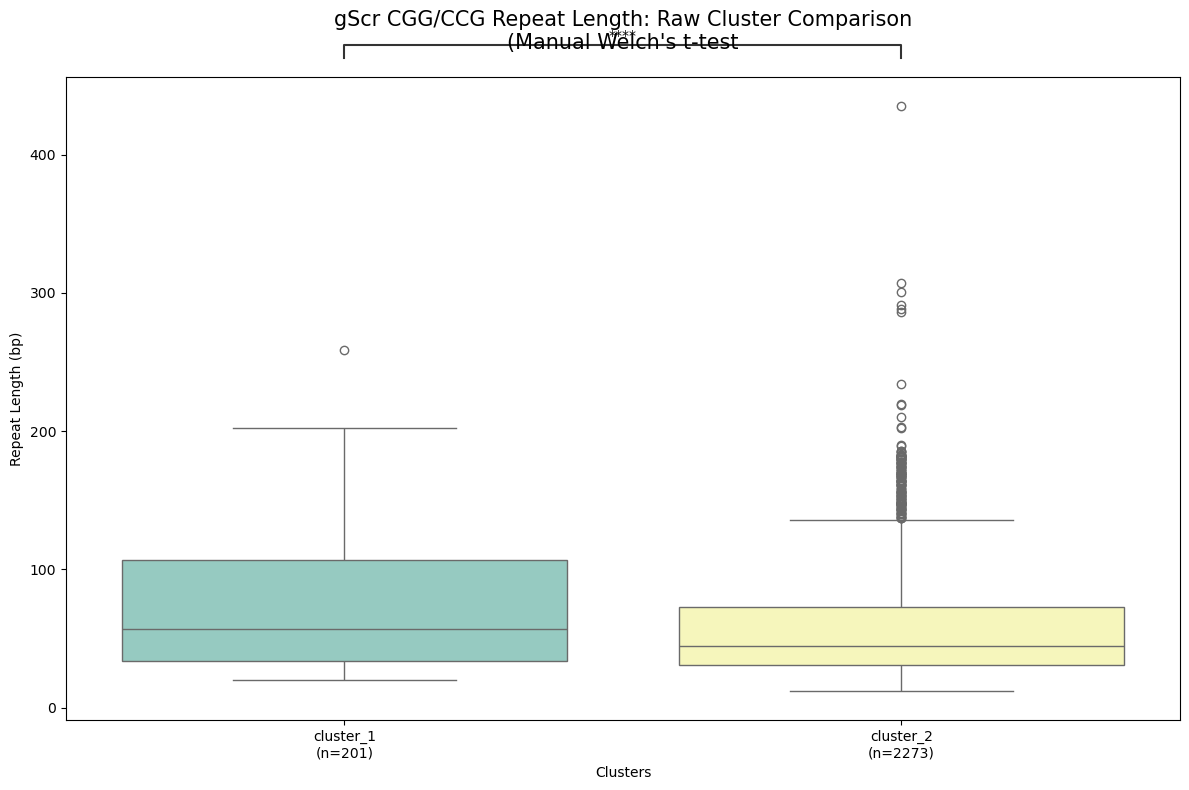

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from itertools import combinations
from statannotations.Annotator import Annotator

# 1. 计算长度并准备数据
clusters = sorted(master_bed_ratio2['deepTools_group'].unique())
counts = master_bed_ratio2['deepTools_group'].value_counts()

# 2. 准备绘图
plt.figure(figsize=(12, 8))
ax = sns.boxplot(data=master_bed_ratio2, x='deepTools_group', y='length', order=clusters, palette='Set3')

# 3. 设置带样本量的标签
new_labels = [f"{c}\n(n={counts[c]})" for c in clusters]
ax.set_xticklabels(new_labels)

# 4. 手动执行 Welch's t-test 并存储 P 值
cluster_pairs = list(combinations(clusters, 2))
p_values = []

for p1, p2 in cluster_pairs:
    g1 = master_bed_ratio2[master_bed_ratio2['deepTools_group'] == p1]['length']
    g2 = master_bed_ratio2[master_bed_ratio2['deepTools_group'] == p2]['length']
    
    # 显式执行 Welch's t-test (equal_var=False)
    _, p_val = stats.ttest_ind(g1, g2, equal_var=False)
    p_values.append(p_val)
    print(f"Comparison {p1} vs {p2}: Welch's p-value = {p_val:.2e}")

# 5. 使用 Annotator 标注手动计算的 P 值
annotator = Annotator(ax, cluster_pairs, data=master_bed_ratio2, x='deepTools_group', y='length', order=clusters)
annotator.configure(text_format='star', loc='outside')
# 直接把我们算好的 p_values 传进去，避开内部参数报错
annotator.set_pvalues(p_values)
annotator.annotate()

# 6. 完善图表
plt.title("gScr CGG/CCG Repeat Length: Raw Cluster Comparison\n(Manual Welch's t-test", fontsize=15, pad=20)
plt.ylabel("Repeat Length (bp)")
plt.xlabel("Clusters")
plt.tight_layout()

plt.show()

In [22]:
cluster2_means = master_bed_ratio2.groupby('deepTools_group')['length'].agg(['count', 'mean', 'std']).reset_index()

# 3. 格式化输出，方便阅读
# 将结果重命名为更具学术性的名称
cluster2_means.columns = ['Cluster', 'N (Count)', 'Mean_Length (bp)', 'Std_Deviation']

print("📊 各 Cluster 序列长度原始数值汇总：")
print(cluster2_means.to_string(index=False))

📊 各 Cluster 序列长度原始数值汇总：
  Cluster  N (Count)  Mean_Length (bp)  Std_Deviation
cluster_1        201         74.059701      50.053436
cluster_2       2273         58.655081      40.645938


In [23]:
import os
clusters = sorted(master_bed_ratio2['deepTools_group'].unique())
output_dir = "5mc_raw2_gScr_cluster_beds_replicate_1"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

for cluster_name in clusters:
    # 过滤出当前 cluster 的数据
    cluster_df2 = master_bed_ratio2[master_bed_ratio2['deepTools_group'] == cluster_name]
    
    # 提取 BED 格式所需的列 (chrom, start, end)
    # 如果你有 name 或 score 列也可以加上，否则可以用默认值
    bed_output = cluster_df2[['chrom', 'start', 'end']]
    
    # 生成文件名，例如: cluster_1.bed, cluster_2.bed ...
    file_path = os.path.join(output_dir, f"{cluster_name}.bed")
    
    # 保存为不带表头、以制表符分隔的 BED 文件
    bed_output.to_csv(file_path, sep='\t', index=False, header=False)
    print(f"✅ 已保存: {file_path} (n={len(cluster_df2)})")

print("\n🚀 所有 BED 文件已就绪，可以开始运行 deepTools。")

✅ 已保存: 5mc_raw2_gScr_cluster_beds_replicate_1/cluster_1.bed (n=201)
✅ 已保存: 5mc_raw2_gScr_cluster_beds_replicate_1/cluster_2.bed (n=2273)

🚀 所有 BED 文件已就绪，可以开始运行 deepTools。


In [ ]:
# 到5hmc分析中


In [30]:
%%bash
computeMatrix reference-point \
    --referencePoint center \
    -b 1000 -a 1000 \
    -R 5mc_raw2_gScr_cluster_beds_replicate_1/cluster_1.bed 5mc_raw2_gScr_cluster_beds_replicate_1/cluster_2.bed \
    -S gScr_dCas9_5hmc.bw \
    -o gScr_dCas9_5hmc.gz \
    -bs 50 \
    -p max  

In [31]:
%%bash
plotHeatmap -m gScr_dCas9_5hmc.gz \
  -out gScr_dCas9_5hmc_cluster2_PureNaN.pdf \
  --colorMap Blues \
  --zMin 0 \
  --zMax 1 \
  --missingDataColor "#808080" \
  --regionsLabel "Cluster 1" "Cluster 2" \
  --samplesLabel "gScr_5hmc" \
  --refPointLabel "CGG-CCG" \
  --heatmapHeight 25 \
  --whatToShow "plot, heatmap and colorbar" \
  --averageType mean

/opt/anaconda3/lib/python3.13/site-packages/deeptools/heatmapper.py:1219: RuntimeWarning:

Mean of empty slice



In [ ]:
# 5modc 


In [32]:
%%bash
computeMatrix reference-point \
    --referencePoint center \
    -b 1000 -a 1000 \
    -R 5mc_raw2_gScr_cluster_beds_replicate_1/cluster_1.bed 5mc_raw2_gScr_cluster_beds_replicate_1/cluster_2.bed \
    -S gScr_dCas9_5modc.bw \
    -o gScr_dCas9_5modc.gz \
    -bs 50 \
    -p max  

In [33]:
%%bash
plotHeatmap -m gScr_dCas9_5modc.gz \
  -out gScr_dCas9_5modc_cluster2_PureNaN.pdf \
  --colorMap Blues \
  --zMin 0 \
  --zMax 1 \
  --missingDataColor "#808080" \
  --regionsLabel "Cluster 1" "Cluster 2" \
  --samplesLabel "gScr_5modc" \
  --refPointLabel "CGG-CCG" \
  --heatmapHeight 25 \
  --whatToShow "plot, heatmap and colorbar" \
  --averageType mean

/opt/anaconda3/lib/python3.13/site-packages/deeptools/heatmapper.py:1219: RuntimeWarning:

Mean of empty slice



In [ ]:
# nanopore set 1 5mc 

In [34]:
%%bash
computeMatrix reference-point \
    --referencePoint center \
    -b 1000 -a 1000 \
    -R 5mc_raw2_gScr_cluster_beds_replicate_1/cluster_1.bed 5mc_raw2_gScr_cluster_beds_replicate_1/cluster_2.bed \
    -S Nanopore_data/barcode02.mc.bw \
    -o gScr_dCas9_5mc_nanopore.gz \
    -bs 50 \
    -p max   

In [35]:
%%bash
plotHeatmap -m gScr_dCas9_5mc_nanopore.gz \
  -out gScr_dCas9_5mc_nanopore_cluster2_PureNaN.pdf \
  --colorMap Blues \
  --zMin 0 \
  --zMax 1 \
  --missingDataColor "#808080" \
  --regionsLabel "Cluster 1" "Cluster 2" \
  --samplesLabel "gScr_5mc_nanopore" \
  --refPointLabel "CGG-CCG" \
  --heatmapHeight 25 \
  --whatToShow "plot, heatmap and colorbar" \
  --averageType mean

/opt/anaconda3/lib/python3.13/site-packages/deeptools/heatmapper.py:1219: RuntimeWarning:

Mean of empty slice



In [ ]:
# nanopore set1 5hmc 

In [36]:
%%bash
computeMatrix reference-point \
    --referencePoint center \
    -b 1000 -a 1000 \
    -R 5mc_raw2_gScr_cluster_beds_replicate_1/cluster_1.bed 5mc_raw2_gScr_cluster_beds_replicate_1/cluster_2.bed \
    -S Nanopore_data/barcode02.hmc.bw \
    -o gScr_dCas9_5hmc_nanopore.gz \
    -bs 50 \
    -p max   

In [37]:
%%bash
plotHeatmap -m gScr_dCas9_5hmc_nanopore.gz \
  -out gScr_dCas9_5hmc_nanopore_cluster2_PureNaN.pdf \
  --colorMap Blues \
  --zMin 0 \
  --zMax 1 \
  --missingDataColor "#808080" \
  --regionsLabel "Cluster 1" "Cluster 2" \
  --samplesLabel "gScr_5hmc_nanopore" \
  --refPointLabel "CGG-CCG" \
  --heatmapHeight 25 \
  --whatToShow "plot, heatmap and colorbar" \
  --averageType mean

/opt/anaconda3/lib/python3.13/site-packages/deeptools/heatmapper.py:1219: RuntimeWarning:

Mean of empty slice



In [ ]:
# nanopore set2 5mc 


In [39]:
%%bash
computeMatrix reference-point \
    --referencePoint center \
    -b 1000 -a 1000 \
    -R 5mc_raw2_gScr_cluster_beds_replicate_1/cluster_1.bed 5mc_raw2_gScr_cluster_beds_replicate_1/cluster_2.bed \
    -S Nanopore_set_2/bc02_5mC.bw \
    -o gScr_dCas9_5mc_nanopore_set2.gz \
    -bs 50 \
    -p max   

In [40]:
%%bash
plotHeatmap -m gScr_dCas9_5mc_nanopore_set2.gz \
  -out gScr_dCas9_5mc_nanopore_cluster2_set2_PureNaN.pdf \
  --colorMap Blues \
  --zMin 0 \
  --zMax 1 \
  --missingDataColor "#808080" \
  --regionsLabel "Cluster 1" "Cluster 2" \
  --samplesLabel "gScr_5mc_nanopore_set2" \
  --refPointLabel "CGG-CCG" \
  --heatmapHeight 25 \
  --whatToShow "plot, heatmap and colorbar" \
  --averageType mean

/opt/anaconda3/lib/python3.13/site-packages/deeptools/heatmapper.py:1219: RuntimeWarning:

Mean of empty slice



In [ ]:
# nanopore set2 5hmc 

In [41]:
%%bash
computeMatrix reference-point \
    --referencePoint center \
    -b 1000 -a 1000 \
    -R 5mc_raw2_gScr_cluster_beds_replicate_1/cluster_1.bed 5mc_raw2_gScr_cluster_beds_replicate_1/cluster_2.bed \
    -S Nanopore_set_2/bc02_5hmC.bw \
    -o gScr_dCas9_5hmc_nanopore_set2.gz \
    -bs 50 \
    -p max   

In [42]:
%%bash
plotHeatmap -m gScr_dCas9_5hmc_nanopore_set2.gz \
  -out gScr_dCas9_5hmc_nanopore_cluster2_set2_PureNaN.pdf \
  --colorMap Blues \
  --zMin 0 \
  --zMax 1 \
  --missingDataColor "#808080" \
  --regionsLabel "Cluster 1" "Cluster 2" \
  --samplesLabel "gScr_5hmc_nanopore_set2" \
  --refPointLabel "CGG-CCG" \
  --heatmapHeight 25 \
  --whatToShow "plot, heatmap and colorbar" \
  --averageType mean

/opt/anaconda3/lib/python3.13/site-packages/deeptools/heatmapper.py:1219: RuntimeWarning:

Mean of empty slice

